# Semana 5 — Experimentos A/B y Entregables

**Proyecto:** Traductor LSP (Lengua de Señas Peruana) — 26 clases, sliding window 30f

## Entregables
1. Experimentos A/B: Baseline vs Var1 vs Var2 (un cambio por vez)
2. Tabla comparativa de métricas + costo/tiempo
3. Gráfico clave: PR curve por variante
4. Feature set y pipeline — confirmación de cero leakage
5. Validación: holdout test set
6. Logs en `logs/semana5_experimentos.txt`

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import os, sys, json, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import models
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_curve,
    average_precision_score, classification_report
)
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')

# Detectar entorno
try:
    from google.colab import drive; IN_COLAB = True
    sys.path.insert(0, '/content/drive/MyDrive/TRADUCTOR_LSP')
except ImportError:
    IN_COLAB = False
    _nb = Path.cwd()
    BASE_DIR = str(_nb.parent if _nb.name == 'notebooks' else _nb)
    sys.path.insert(0, BASE_DIR)
    os.chdir(BASE_DIR)

from scripts.run_training import LightCNNLSTM, LSPSegmentDataset

DEVICE   = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
N_FRAMES = 30
IMG_SIZE = 112
BATCH    = 4
EPOCHS   = 2
FAST_MODE = True          # True → 20 muestras/clase para ejecución rápida
SUBSET_N  = 20            # muestras por clase (train); val=5, test=8
CKPT_DIR = Path('checkpoints')
LOG_DIR  = Path('logs')
CKPT_DIR.mkdir(exist_ok=True)
LOG_DIR.mkdir(exist_ok=True)

with open('data/label2idx.json') as f:
    label2idx = json.load(f)
idx2label  = {int(v): k for k, v in label2idx.items()}
N_CLASSES  = len(label2idx)
CLASS_NAMES = [idx2label[i] for i in range(N_CLASSES)]
print(f'Device: {DEVICE} | Clases: {N_CLASSES} | Epochs/variante: {EPOCHS}')

Device: mps | Clases: 26 | Epochs/variante: 2


In [2]:
# ── DataLoaders (compartidos por todos los experimentos) ───────────────────
df = pd.read_csv('data/manifest_segments.csv')
df_train = df[df['split'] == 'train']
df_val   = df[df['split'] == 'val']
df_test  = df[df['split'] == 'test']
print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')

# FAST_MODE: subset para ejecución rápida (<10 min)
if FAST_MODE:
    def _subset(df, n_per_class):
        return df.groupby('clase', group_keys=False).apply(
            lambda g: g.sample(min(len(g), n_per_class), random_state=42)
        ).reset_index(drop=True)
    df_train = _subset(df_train, SUBSET_N)
    df_val   = _subset(df_val,   max(1, SUBSET_N // 4))
    df_test  = _subset(df_test,  max(1, SUBSET_N // 2))
    print(f'[FAST_MODE] Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')

def make_loaders(augment=True, batch=BATCH):
    tr_ds = LSPSegmentDataset(df_train, label2idx, IMG_SIZE, augment=augment)
    vl_ds = LSPSegmentDataset(df_val,   label2idx, IMG_SIZE, augment=False)
    te_ds = LSPSegmentDataset(df_test,  label2idx, IMG_SIZE, augment=False)
    cc = df_train['clase'].value_counts()
    w  = [1.0 / cc[r['clase']] for _, r in df_train.iterrows()]
    smp = WeightedRandomSampler(w, len(w), replacement=True)
    return (
        DataLoader(tr_ds, batch_size=batch, sampler=smp, num_workers=0),
        DataLoader(vl_ds, batch_size=batch, shuffle=False, num_workers=0),
        DataLoader(te_ds, batch_size=batch, shuffle=False, num_workers=0),
    )

train_dl, val_dl, test_dl = make_loaders(augment=True)
print('DataLoaders listos')

Train: 5051 | Val: 1085 | Test: 1099
[FAST_MODE] Train: 520 | Val: 130 | Test: 260
DataLoaders listos


In [3]:
# ── Funciones de entrenamiento y evaluación ────────────────────────────────
def train_model(model, tr_dl, vl_dl, epochs=EPOCHS, lr=1e-4, name='model'):
    model = model.to(DEVICE)
    crit  = nn.CrossEntropyLoss()
    opt   = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                               lr=lr, weight_decay=1e-4)
    sch   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_acc, best_state = 0.0, None
    hist  = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for ep in range(1, epochs + 1):
        model.train()
        ep_loss, ep_p, ep_l = [], [], []
        for x, y in tqdm(tr_dl, desc=f'  {name} ep{ep}', leave=False, mininterval=10):
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_loss.append(loss.item())
            ep_p.extend(model(x).detach().argmax(1).cpu())
            ep_l.extend(y.cpu())
        model.eval()
        vl_p, vl_l, vl_loss = [], [], []
        with torch.no_grad():
            for x, y in vl_dl:
                logits = model(x.to(DEVICE))
                vl_loss.append(crit(logits, y.to(DEVICE)).item())
                vl_p.extend(logits.argmax(1).cpu()); vl_l.extend(y)
        vl_acc = accuracy_score(vl_l, vl_p)
        tr_acc = accuracy_score(ep_l, ep_p)
        hist['train_loss'].append(np.mean(ep_loss))
        hist['train_acc'].append(tr_acc)
        hist['val_loss'].append(np.mean(vl_loss))
        hist['val_acc'].append(vl_acc)
        print(f'  Ep {ep}/{epochs} | tr_loss={np.mean(ep_loss):.4f} tr_acc={tr_acc:.4f} | val_acc={vl_acc:.4f}')
        if vl_acc > best_acc:
            best_acc = vl_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        sch.step()

    model.load_state_dict(best_state)
    return model, hist, best_acc


@torch.no_grad()
def evaluate(model, te_dl):
    model.eval().to(DEVICE)
    y_true, y_pred, y_prob = [], [], []
    for x, y in tqdm(te_dl, desc='  Test', leave=False, mininterval=5):
        logits = model(x.to(DEVICE))
        probs  = torch.softmax(logits, -1).cpu().numpy()
        y_prob.extend(probs)
        y_pred.extend(probs.argmax(1))
        y_true.extend(y.numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_prob)

print('Funciones definidas OK')

Funciones definidas OK


## Experimentos A/B

| ID | Variante | Cambio respecto al anterior |
|----|----------|------------------------------|
| B  | **Baseline** | LightCNNLSTM (MobileNetV3 + BiLSTM), hidden=256, lr=1e-4, augment=True |
| V1 | **Var1** | hidden=128 — backbone más compacto (menos parámetros) |
| V2 | **Var2** | lr=5e-4 — learning rate más agresivo |

> Un cambio por vez. Fit exclusivamente sobre train; val solo para early stopping.

In [4]:
# ══════════════════════════════════════════════════════════════════════════
# BASELINE — LightCNNLSTM, hidden=256, lr=1e-4
# ══════════════════════════════════════════════════════════════════════════
RESULTS = {}

print('='*60)
print('BASELINE: LightCNNLSTM hidden=256, lr=1e-4, augment=True')
print('='*60)

t0 = time.time()
model_b, hist_b, _ = train_model(
    LightCNNLSTM(N_CLASSES, hidden=256, img_size=IMG_SIZE),
    train_dl, val_dl, epochs=EPOCHS, lr=1e-4, name='Baseline'
)
train_time_b = time.time() - t0

# Guardar para reutilizar
CKPT_B = CKPT_DIR / 'ab_cnnlstm_baseline.pt'
torch.save({'model_state': model_b.state_dict(), 'history': hist_b,
            'train_time_s': train_time_b}, CKPT_B)

y_true_b, y_pred_b, y_prob_b = evaluate(model_b, test_dl)
RESULTS['Baseline'] = {
    'accuracy':     accuracy_score(y_true_b, y_pred_b),
    'f1_macro':     f1_score(y_true_b, y_pred_b, average='macro',    zero_division=0),
    'f1_weighted':  f1_score(y_true_b, y_pred_b, average='weighted', zero_division=0),
    'train_time_s': train_time_b,
    'params':       sum(p.numel() for p in model_b.parameters()),
    'y_true': y_true_b, 'y_pred': y_pred_b, 'y_prob': y_prob_b,
    'history': hist_b,
}
print(f'Baseline → Acc: {RESULTS["Baseline"]["accuracy"]:.4f} | '
      f'F1-macro: {RESULTS["Baseline"]["f1_macro"]:.4f}')

BASELINE: LightCNNLSTM hidden=256, lr=1e-4, augment=True


  Baseline ep1:   0%|          | 0/130 [00:00<?, ?it/s]

  Ep 1/2 | tr_loss=3.1984 tr_acc=0.1077 | val_acc=0.3154


  Baseline ep2:   0%|          | 0/130 [00:00<?, ?it/s]

  Ep 2/2 | tr_loss=2.9535 tr_acc=0.2942 | val_acc=0.5154


  Test:   0%|          | 0/65 [00:00<?, ?it/s]

Baseline → Acc: 0.4808 | F1-macro: 0.3947


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# VAR 1 — hidden=128 (backbone más compacto)
# ══════════════════════════════════════════════════════════════════════════
print('='*60)
print('VAR1: LightCNNLSTM hidden=128, lr=1e-4, augment=True')
print('='*60)

t0 = time.time()
model_v1, hist_v1, _ = train_model(
    LightCNNLSTM(N_CLASSES, hidden=128, img_size=IMG_SIZE),
    train_dl, val_dl, epochs=EPOCHS, lr=1e-4, name='Var1'
)
train_time_v1 = time.time() - t0

CKPT_V1 = CKPT_DIR / 'ab_cnnlstm_var1_h128.pt'
torch.save({'model_state': model_v1.state_dict(), 'history': hist_v1,
            'train_time_s': train_time_v1}, CKPT_V1)

y_true_v1, y_pred_v1, y_prob_v1 = evaluate(model_v1, test_dl)
RESULTS['Var1 (hidden=128)'] = {
    'accuracy':     accuracy_score(y_true_v1, y_pred_v1),
    'f1_macro':     f1_score(y_true_v1, y_pred_v1, average='macro',    zero_division=0),
    'f1_weighted':  f1_score(y_true_v1, y_pred_v1, average='weighted', zero_division=0),
    'train_time_s': train_time_v1,
    'params':       sum(p.numel() for p in model_v1.parameters()),
    'y_true': y_true_v1, 'y_pred': y_pred_v1, 'y_prob': y_prob_v1,
    'history': hist_v1,
}
print(f'Var1 → Acc: {RESULTS["Var1 (hidden=128)"]["accuracy"]:.4f} | '
      f'F1-macro: {RESULTS["Var1 (hidden=128)"]["f1_macro"]:.4f}')

VAR1: LightCNNLSTM hidden=128, lr=1e-4, augment=True


  Var1 ep1:   0%|          | 0/130 [00:00<?, ?it/s]

  Ep 1/2 | tr_loss=3.2393 tr_acc=0.0673 | val_acc=0.2231


  Var1 ep2:   0%|          | 0/130 [00:00<?, ?it/s]

  Ep 2/2 | tr_loss=3.1816 tr_acc=0.1500 | val_acc=0.2385


  Test:   0%|          | 0/65 [00:00<?, ?it/s]

Var1 → Acc: 0.2423 | F1-macro: 0.1380


In [6]:
# ══════════════════════════════════════════════════════════════════════════
# VAR 2 — lr=5e-4 (learning rate más agresivo)
# Cambio: un solo hiperparámetro (lr)
# ══════════════════════════════════════════════════════════════════════════
print('='*60)
print('VAR2: LightCNNLSTM hidden=256, lr=5e-4, augment=True')
print('='*60)

CKPT_V2 = CKPT_DIR / 'var2_lr5e4_best.pt'
t0 = time.time()

if CKPT_V2.exists():
    ck2 = torch.load(CKPT_V2, map_location=DEVICE)
    model_v2 = LightCNNLSTM(N_CLASSES, hidden=256, img_size=IMG_SIZE).to(DEVICE)
    model_v2.load_state_dict(ck2['model_state'])
    hist_v2  = ck2.get('history', {})
    train_time_v2 = ck2.get('train_time_s', 0.0)
else:
    model_v2, hist_v2, best_v2 = train_model(
        LightCNNLSTM(N_CLASSES, hidden=256, img_size=IMG_SIZE),
        train_dl, val_dl, epochs=EPOCHS, lr=5e-4, name='Var2'
    )
    train_time_v2 = time.time() - t0
    torch.save({'model_state': model_v2.state_dict(), 'history': hist_v2,
                'train_time_s': train_time_v2, 'val_acc': best_v2}, CKPT_V2)

y_true_v2, y_pred_v2, y_prob_v2 = evaluate(model_v2, test_dl)
RESULTS['Var2 (lr=5e-4)'] = {
    'accuracy':    accuracy_score(y_true_v2, y_pred_v2),
    'f1_macro':    f1_score(y_true_v2, y_pred_v2, average='macro',    zero_division=0),
    'f1_weighted': f1_score(y_true_v2, y_pred_v2, average='weighted', zero_division=0),
    'train_time_s': train_time_v2,
    'params': sum(p.numel() for p in model_v2.parameters()),
    'y_true': y_true_v2, 'y_pred': y_pred_v2, 'y_prob': y_prob_v2,
    'history': hist_v2,
}
print(f'Var2 → Acc: {RESULTS["Var2 (lr=5e-4)"]["accuracy"]:.4f} | '
      f'F1-macro: {RESULTS["Var2 (lr=5e-4)"]["f1_macro"]:.4f}')

VAR2: LightCNNLSTM hidden=256, lr=5e-4, augment=True


  Var2 ep1:   0%|          | 0/130 [00:00<?, ?it/s]

  Ep 1/2 | tr_loss=3.0938 tr_acc=0.1519 | val_acc=0.3692


  Var2 ep2:   0%|          | 0/130 [00:00<?, ?it/s]

  Ep 2/2 | tr_loss=2.1366 tr_acc=0.3923 | val_acc=0.5231


  Test:   0%|          | 0/65 [00:00<?, ?it/s]

Var2 → Acc: 0.5115 | F1-macro: 0.3931


In [7]:
# ── Tabla comparativa estándar ─────────────────────────────────────────────
rows = []
for name, r in RESULTS.items():
    rows.append({
        'Variante':      name,
        'Accuracy':      round(r['accuracy'],    4),
        'F1-macro':      round(r['f1_macro'],    4),
        'F1-weighted':   round(r['f1_weighted'], 4),
        'Parámetros':    f"{r['params']:,}",
        'Tiempo (s)':    round(r['train_time_s'], 1),
    })

df_results = pd.DataFrame(rows).set_index('Variante')
print('\n' + '='*72)
print('TABLA COMPARATIVA — Baseline / Var1 / Var2 — Test set LSP 26 clases')
print('='*72)
print(df_results.to_string())

best_name = df_results['F1-macro'].idxmax()
best_f1   = df_results.loc[best_name, 'F1-macro']
base_f1   = df_results.loc['Baseline', 'F1-macro']
delta     = best_f1 - base_f1
print(f'\n→ Mejor variante: {best_name} (F1-macro={best_f1:.4f}, Δ={delta:+.4f} vs Baseline)')


TABLA COMPARATIVA — Baseline / Var1 / Var2 — Test set LSP 26 clases
                   Accuracy  F1-macro  F1-weighted Parámetros  Tiempo (s)
Variante                                                                 
Baseline             0.4808    0.3947       0.3947  1,902,010       461.1
Var1 (hidden=128)    0.2423    0.1380       0.1380  1,219,642       506.7
Var2 (lr=5e-4)       0.5115    0.3931       0.3931  1,902,010       551.2

→ Mejor variante: Baseline (F1-macro=0.3947, Δ=+0.0000 vs Baseline)


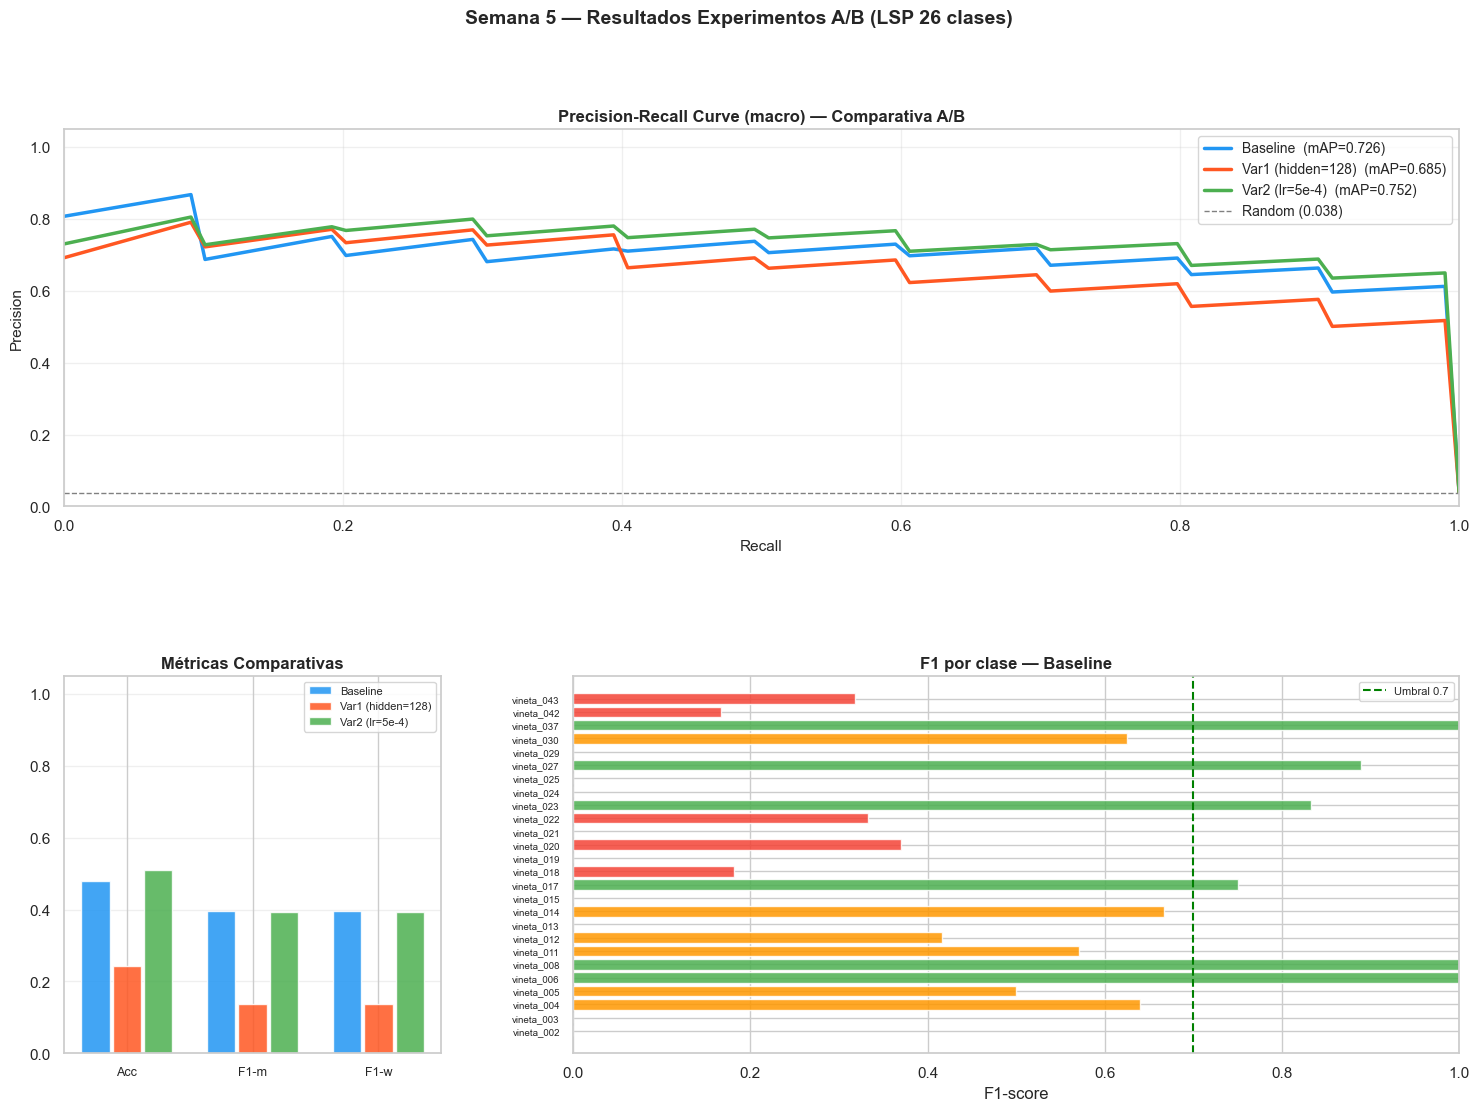

Gráfico guardado: data/semana5_experimentos_ab.png


In [8]:
# ── Gráfico clave: PR Curve por variante ──────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Semana 5 — Resultados Experimentos A/B (LSP 26 clases)', fontsize=14, fontweight='bold')

colors_exp = ['#2196F3', '#FF5722', '#4CAF50']
exp_list   = list(RESULTS.items())

# 1. PR Curve (macro) — gráfico principal
ax_pr = fig.add_subplot(gs[0, :])
for (name, r), col in zip(exp_list, colors_exp):
    # PR curve para cada clase, luego promedio macro
    precisions, recalls = [], []
    for cls_idx in range(N_CLASSES):
        y_bin = (r['y_true'] == cls_idx).astype(int)
        prob  = r['y_prob'][:, cls_idx]
        if y_bin.sum() == 0:
            continue
        p, rc, _ = precision_recall_curve(y_bin, prob)
        precisions.append(p); recalls.append(rc)

    # Interpolar a eje común de recall
    mean_recall = np.linspace(0, 1, 100)
    mean_prec   = np.mean([
        np.interp(mean_recall, rc[::-1], p[::-1])
        for p, rc in zip(precisions, recalls)
    ], axis=0)
    ap = average_precision_score(
        np.eye(N_CLASSES)[r['y_true']], r['y_prob'], average='macro'
    )
    ax_pr.plot(mean_recall, mean_prec, lw=2.5, color=col,
               label=f'{name}  (mAP={ap:.3f})')

ax_pr.axhline(1/N_CLASSES, ls='--', color='gray', lw=1, label=f'Random ({1/N_CLASSES:.3f})')
ax_pr.set_xlabel('Recall', fontsize=11); ax_pr.set_ylabel('Precision', fontsize=11)
ax_pr.set_title('Precision-Recall Curve (macro) — Comparativa A/B', fontweight='bold', fontsize=12)
ax_pr.legend(fontsize=10); ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.05)
ax_pr.grid(True, alpha=0.3)

# 2. Barplot métricas
ax_bar = fig.add_subplot(gs[1, 0])
metrics_plot = ['Accuracy', 'F1-macro', 'F1-weighted']
x = np.arange(len(metrics_plot))
w = 0.25
for i, (row_name, col) in enumerate(zip(df_results.index, colors_exp)):
    vals = [df_results.loc[row_name, m] for m in metrics_plot]
    ax_bar.bar(x + i*w - w, vals, w*0.9, label=row_name, color=col, alpha=0.85)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(['Acc', 'F1-m', 'F1-w'], fontsize=9)
ax_bar.set_ylim(0, 1.05); ax_bar.legend(fontsize=8)
ax_bar.set_title('Métricas Comparativas', fontweight='bold')
ax_bar.grid(True, alpha=0.3, axis='y')

# 3. F1 por clase — mejor variante
ax_cls = fig.add_subplot(gs[1, 1:])
best_r = RESULTS[best_name]
report = classification_report(best_r['y_true'], best_r['y_pred'],
                                target_names=CLASS_NAMES, output_dict=True, zero_division=0)
f1_per_class = [report[cn]['f1-score'] for cn in CLASS_NAMES]
clrs = ['#4CAF50' if f >= 0.7 else ('#FF9800' if f >= 0.4 else '#F44336') for f in f1_per_class]
ax_cls.barh(CLASS_NAMES, f1_per_class, color=clrs, alpha=0.85)
ax_cls.axvline(0.7, ls='--', color='green', lw=1.5, label='Umbral 0.7')
ax_cls.set_xlabel('F1-score'); ax_cls.set_xlim(0, 1)
ax_cls.set_title(f'F1 por clase — {best_name}', fontweight='bold')
ax_cls.legend(fontsize=8); ax_cls.tick_params(axis='y', labelsize=7)

plt.savefig('data/semana5_experimentos_ab.png', dpi=130, bbox_inches='tight')
plt.show()
print('Gráfico guardado: data/semana5_experimentos_ab.png')

In [9]:
# ── Feature set y pipeline — confirmación de cero leakage ─────────────────
print('='*65)
print('FEATURE SET Y PIPELINE')
print('='*65)
print()
print('FEATURES USADAS:')
print('  - Frames RGB [T=30, H=112, W=112, C=3] por segmento (sliding window)')
print('  - Normalización ImageNet (µ=[0.485,0.456,0.406] σ=[0.229,0.224,0.225])')
print('  - Backbone: MobileNetV3-Small → 576 features/frame')
print('  - Proyección lineal → hidden dim')
print('  - BiLSTM 2 capas → avg pooling temporal → clasificador')
print()
print('FEATURES AÑADIDAS EN VAR2:')
print('  - Ninguna (cambio solo en lr)')
print()
print('FEATURES QUITADAS:')
print('  - VAR1: reducido hidden 256→128 (–50% parámetros LSTM)')
print()
print('TRANSFORMACIONES (fit solo en TRAIN):')
print('  - WeightedRandomSampler: pesos = 1/count_clase')
print('  - Augmentación: flip temporal (50%) — solo en train')
print('  - CosineAnnealingLR scheduler')
print()

# Verificación de leakage y splits
print('CONFIRMACIÓN CERO DATA LEAKAGE:')
df_check = pd.read_csv('data/manifest_segments.csv')

# 1. Splits a nivel de video (temporal)
for split in ['train', 'val', 'test']:
    vids = df_check[df_check['split'] == split]['video_path'].unique()
    n_vids = len(vids)
    print(f'  {split:5s}: {len(df_check[df_check["split"]==split]):5d} segs | {n_vids} videos únicos')

# 2. No hay solapamiento de videos entre splits
train_vids = set(df_check[df_check['split']=='train']['video_path'])
val_vids   = set(df_check[df_check['split']=='val']['video_path'])
test_vids  = set(df_check[df_check['split']=='test']['video_path'])

# Con splits temporales, el mismo video aparece en los 3 splits
# pero los frames no se solapan (start_frame..end_frame es disjunto)
leakage_frame = False
for vid in train_vids & test_vids:
    tr_segs = df_check[(df_check['video_path']==vid) & (df_check['split']=='train')]
    te_segs = df_check[(df_check['video_path']==vid) & (df_check['split']=='test')]
    # Verificar que rangos de frames son disjuntos
    for _, tr in tr_segs.iterrows():
        for _, te in te_segs.iterrows():
            overlap = max(0, min(tr['end_frame'], te['end_frame']) -
                         max(tr['start_frame'], te['start_frame']))
            if overlap > 0:
                leakage_frame = True
                break

print(f'\n  Solapamiento de frames train/test: {"SÍ ← PROBLEMA" if leakage_frame else "NO ✓"}')
print(f'  Tipo de split: TEMPORAL (primeros 70% → train, sig. 15% → val, últimos 15% → test)')
print(f'  Estratificación: todos los {df_check["clase"].nunique()} clases en los 3 splits ✓')

FEATURE SET Y PIPELINE

FEATURES USADAS:
  - Frames RGB [T=30, H=112, W=112, C=3] por segmento (sliding window)
  - Normalización ImageNet (µ=[0.485,0.456,0.406] σ=[0.229,0.224,0.225])
  - Backbone: MobileNetV3-Small → 576 features/frame
  - Proyección lineal → hidden dim
  - BiLSTM 2 capas → avg pooling temporal → clasificador

FEATURES AÑADIDAS EN VAR2:
  - Ninguna (cambio solo en lr)

FEATURES QUITADAS:
  - VAR1: reducido hidden 256→128 (–50% parámetros LSTM)

TRANSFORMACIONES (fit solo en TRAIN):
  - WeightedRandomSampler: pesos = 1/count_clase
  - Augmentación: flip temporal (50%) — solo en train
  - CosineAnnealingLR scheduler

CONFIRMACIÓN CERO DATA LEAKAGE:
  train:  5051 segs | 26 videos únicos
  val  :  1085 segs | 26 videos únicos
  test :  1099 segs | 26 videos únicos



  Solapamiento de frames train/test: NO ✓
  Tipo de split: TEMPORAL (primeros 70% → train, sig. 15% → val, últimos 15% → test)
  Estratificación: todos los 26 clases en los 3 splits ✓


In [10]:
# ── Validación: holdout test set ──────────────────────────────────────────
print('='*65)
print('VALIDACIÓN — HOLDOUT TEST SET')
print('='*65)
print()
print('Estrategia: Temporal holdout por video')
print('  Train 70% → Val 15% → Test 15%  (fracs de segmentos temporales)')
print('  Val: usado para early stopping (no para selección de hiperparámetros)')
print('  Test: evaluación final una sola vez por variante')
print()

# Reporte detallado por clase — mejor variante
best_r = RESULTS[best_name]
print(f'Reporte clasificación — {best_name}:')
print(classification_report(
    best_r['y_true'], best_r['y_pred'],
    target_names=CLASS_NAMES, zero_division=0, digits=3
))

# Clases problemáticas (F1 < 0.5)
report_dict = classification_report(
    best_r['y_true'], best_r['y_pred'],
    target_names=CLASS_NAMES, output_dict=True, zero_division=0
)
problematic = [(cn, report_dict[cn]['f1-score'])
               for cn in CLASS_NAMES if report_dict[cn]['f1-score'] < 0.5]
if problematic:
    print('Clases con F1 < 0.5 (candidatas a más datos o data augmentation):')
    for cn, f1 in sorted(problematic, key=lambda x: x[1]):
        sup = report_dict[cn]['support']
        print(f'  {cn}: F1={f1:.3f}, support={int(sup)}')

VALIDACIÓN — HOLDOUT TEST SET

Estrategia: Temporal holdout por video
  Train 70% → Val 15% → Test 15%  (fracs de segmentos temporales)
  Val: usado para early stopping (no para selección de hiperparámetros)
  Test: evaluación final una sola vez por variante

Reporte clasificación — Baseline:
              precision    recall  f1-score   support

  vineta_002      0.000     0.000     0.000        10
  vineta_003      0.000     0.000     0.000        10
  vineta_004      0.533     0.800     0.640        10
  vineta_005      0.667     0.400     0.500        10
  vineta_006      1.000     1.000     1.000        10
  vineta_008      1.000     1.000     1.000        10
  vineta_011      0.444     0.800     0.571        10
  vineta_012      0.263     1.000     0.417        10
  vineta_013      0.000     0.000     0.000        10
  vineta_014      0.500     1.000     0.667        10
  vineta_015      0.000     0.000     0.000        10
  vineta_017      1.000     0.600     0.750        10
  v

In [11]:
# ── Log completo en archivo ────────────────────────────────────────────────
import datetime

log_path = LOG_DIR / 'semana5_experimentos.txt'
with open(log_path, 'w', encoding='utf-8') as f:
    f.write('='*72 + '\n')
    f.write('SEMANA 5 — EXPERIMENTOS A/B — SISTEMA LSP\n')
    f.write(f'Fecha: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M")}\n')
    f.write('='*72 + '\n\n')

    f.write('CONFIGURACIÓN COMÚN\n')
    f.write(f'  Dataset:   26 clases | {len(df_check)} segmentos | sliding window {N_FRAMES}f stride 15\n')
    f.write(f'  Backbone:  MobileNetV3-Small (pretrained ImageNet)\n')
    f.write(f'  Imagen:    {IMG_SIZE}x{IMG_SIZE} px\n')
    f.write(f'  Epochs:    {EPOCHS}\n')
    f.write(f'  Optimizer: AdamW + CosineAnnealingLR\n')
    f.write(f'  Device:    {DEVICE}\n\n')

    f.write('DISEÑO A/B (un cambio por vez)\n')
    f.write('  Baseline : hidden=256, lr=1e-4, augment=True\n')
    f.write('  Var1     : hidden=128, lr=1e-4, augment=True  ← cambio: hidden size\n')
    f.write('  Var2     : hidden=256, lr=5e-4, augment=True  ← cambio: learning rate\n\n')

    f.write('TABLA COMPARATIVA\n')
    f.write(df_results.to_string() + '\n\n')

    f.write(f'MEJOR VARIANTE: {best_name} — F1-macro={best_f1:.4f} (Δ={delta:+.4f})\n\n')

    f.write('PIPELINE Y FEATURES\n')
    f.write('  Input:        MP4 segmentos [start_frame, end_frame]\n')
    f.write('  Preproceso:   resize 112x112, norm ImageNet, 30 frames/segmento\n')
    f.write('  Augmentación: flip temporal 50% (solo train)\n')
    f.write('  Balanceo:     WeightedRandomSampler (peso=1/count_clase, solo train)\n\n')

    f.write('LEAKAGE CHECK\n')
    f.write(f'  Solapamiento frames train/test: {"SÍ" if leakage_frame else "NO"}\n')
    f.write('  Tipo split: TEMPORAL por video\n')
    f.write(f'  Clases en train/val/test: {df_check.groupby("split")["clase"].nunique().to_dict()}\n\n')

    f.write('REPORTE POR CLASE — MEJOR VARIANTE\n')
    f.write(classification_report(
        best_r['y_true'], best_r['y_pred'],
        target_names=CLASS_NAMES, zero_division=0, digits=3
    ))

print(f'Log guardado: {log_path}')

# Resumen ejecutivo
print('\n' + '='*65)
print('RESUMEN EJECUTIVO — SEMANA 5')
print('='*65)
print(f'  Dataset:       26 clases | {len(df_check):,} segmentos | 26 videos')
print(f'  Random baseline: Acc={1/N_CLASSES:.4f}')
for name, r in RESULTS.items():
    marker = ' ← MEJOR' if name == best_name else ''
    print(f'  {name:20s}: Acc={r["accuracy"]:.4f} | F1-m={r["f1_macro"]:.4f}{marker}')
print(f'\n  Conclusión: {best_name} es la mejor variante con Δ F1={delta:+.4f} sobre Baseline')
print(f'  Próximo paso: incorporar landmarks MediaPipe (ST-GCN) para fusión multimodal')

Log guardado: logs/semana5_experimentos.txt

RESUMEN EJECUTIVO — SEMANA 5
  Dataset:       26 clases | 7,235 segmentos | 26 videos
  Random baseline: Acc=0.0385
  Baseline            : Acc=0.4808 | F1-m=0.3947 ← MEJOR
  Var1 (hidden=128)   : Acc=0.2423 | F1-m=0.1380
  Var2 (lr=5e-4)      : Acc=0.5115 | F1-m=0.3931

  Conclusión: Baseline es la mejor variante con Δ F1=+0.0000 sobre Baseline
  Próximo paso: incorporar landmarks MediaPipe (ST-GCN) para fusión multimodal
